# Primero pre-procesamos los datos
- Para ello usamos librerías como pandas, seaborn y matplotlib para entender los datos

In [ ]:
# ===============================
# 1. Importar librerías
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import normaltest, zscore

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# ===============================
# 2. Cargar datos
# ===============================

ruta = r'C:\Users\danie\OneDrive\Escritorio\Ciclo 6\Data Mining\Proyecto - Informe Parcial\Data (Raw)\Obfuscated-MalMem2022.csv'
df = pd.read_csv(ruta)

print(f"Registros: {df.shape[0]}, Variables: {df.shape[1]}")
df.head()


Registros: 58596, Variables: 57


,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,...,222,26,27,118,0,120,88,0,8,Benign
3,Benign,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,...,222,26,27,118,0,120,88,0,8,Benign
4,Benign,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,...,222,26,24,118,0,124,87,0,8,Benign


Métricas de calidad del dataset:
- Registros totales: 58596
- Variables totales: 57
- Nulos totales: 0
- Duplicados: 534


Series([], dtype: int64)

C:\Users\danie\AppData\Local\Temp\ipykernel_38368\2859242015.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette="Set2")


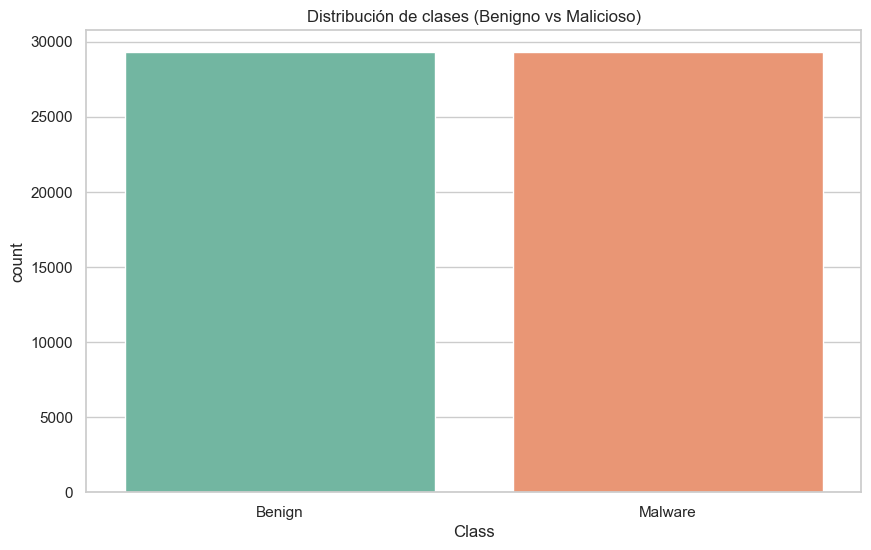

In [13]:
# ===============================
# 3. Calidad de datos
# ===============================
print("Métricas de calidad del dataset:")
print(f"- Registros totales: {df.shape[0]}")
print(f"- Variables totales: {df.shape[1]}")
print(f"- Nulos totales: {df.isna().sum().sum()}")
print(f"- Duplicados: {df.duplicated().sum()}")

# Conteo de nulos por variable
nulls = df.isna().sum()
display(nulls[nulls > 0])

# Distribución de clases
sns.countplot(x="Class", data=df, palette="Set2")
plt.title("Distribución de clases (Benigno vs Malicioso)")
plt.show()


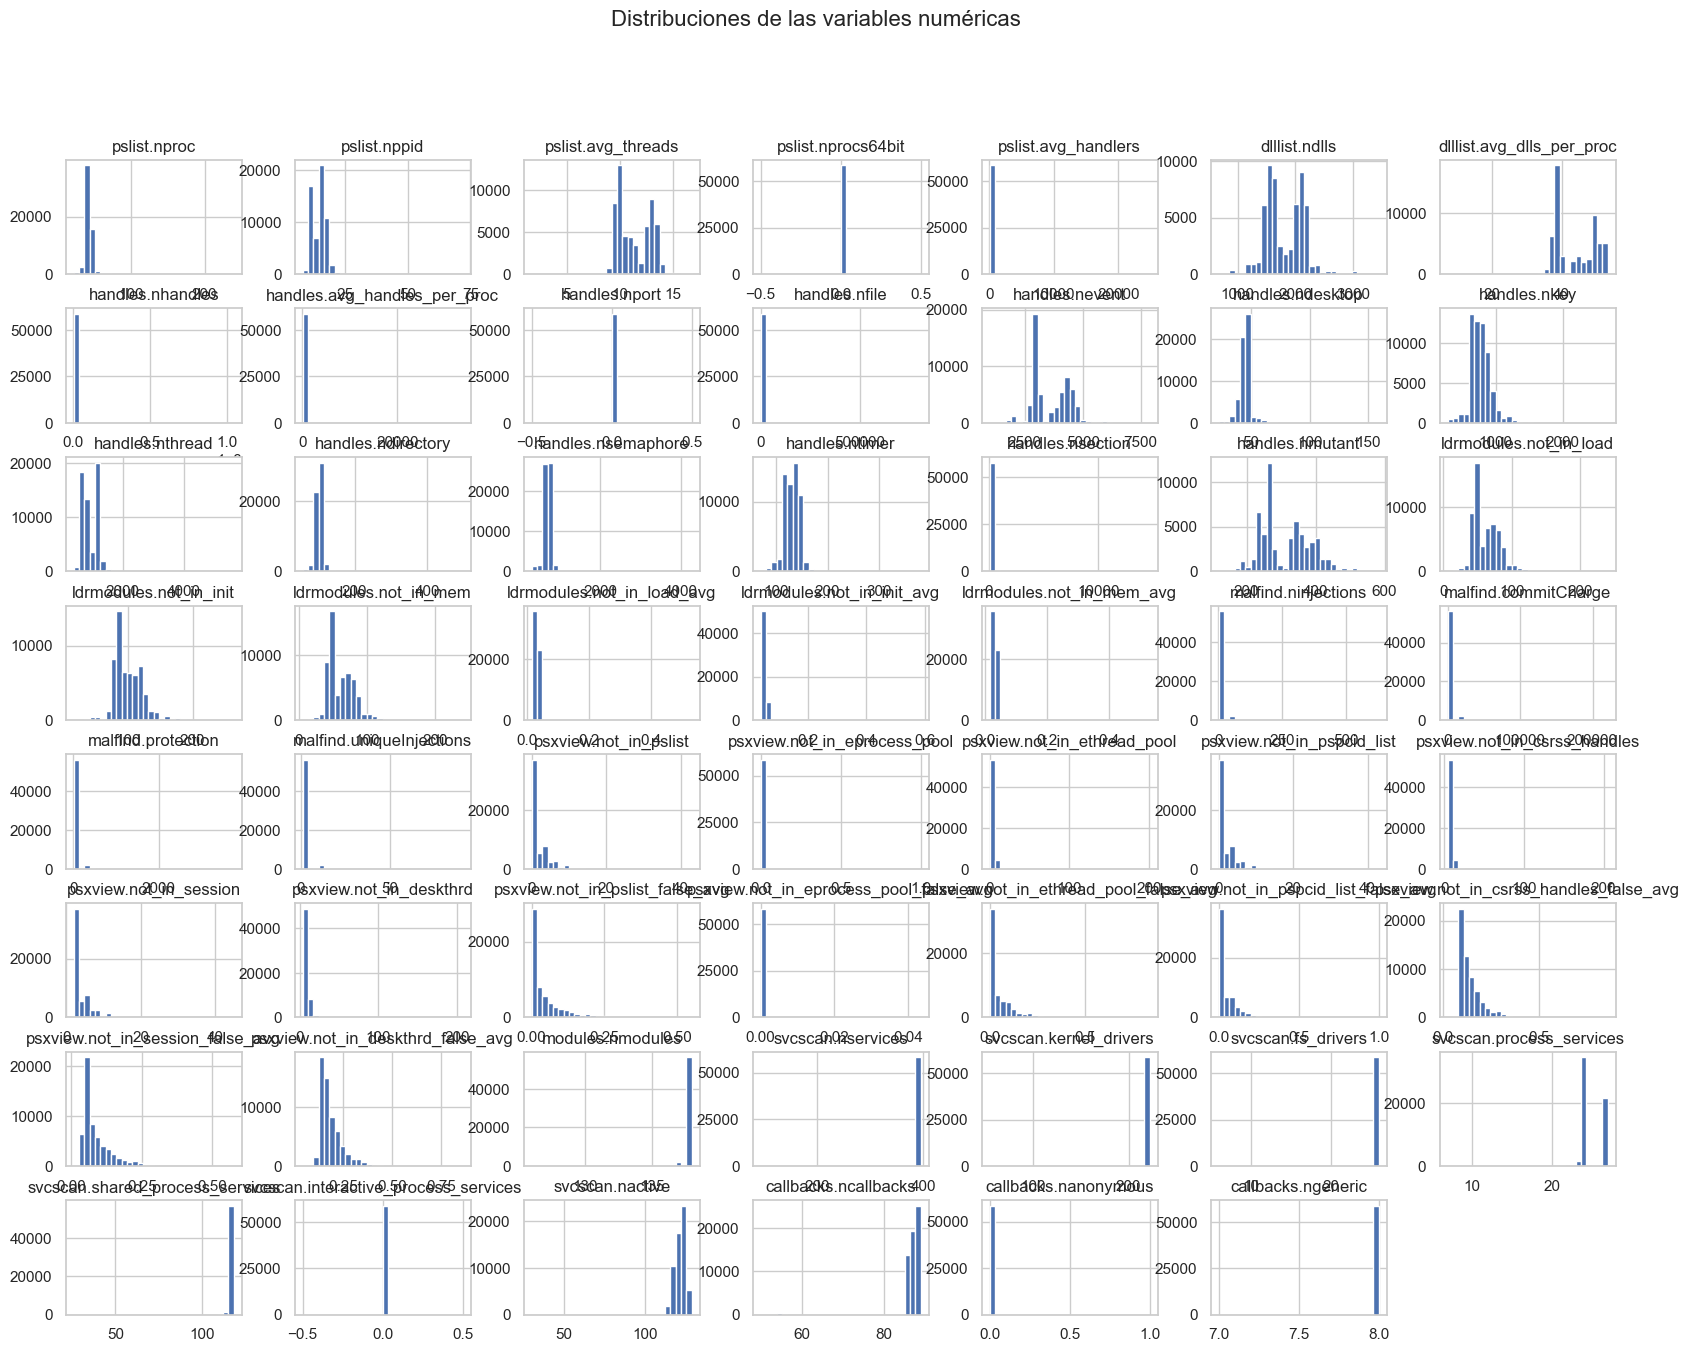

In [14]:
# ===============================
# 4. Distribuciones univariadas
# ===============================
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(bins=30, figsize=(20,15))
plt.suptitle("Distribuciones de las variables numéricas", fontsize=16)
plt.show()

In [15]:
# ===============================
# 5. Definir función para remover outliers
# ===============================
def remove_outliers(data, col):
    vals = data[col].dropna()
    # Test de normalidad
    stat, p = normaltest(vals)
    if p > 0.05:  # Aproximadamente normal
        z_scores = np.abs(zscore(vals))
        mask = z_scores < 3
    else:  # No normal
        Q1, Q3 = np.percentile(vals, [25, 75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        mask = (vals >= lower) & (vals <= upper)
    return data.loc[mask.index[mask]]

# Crear dataset sin outliers
df_no_outliers = df.copy()
for col in numeric_cols:
    df_no_outliers = remove_outliers(df_no_outliers, col)

print(f"Dataset original: {df.shape[0]} registros")
print(f"Dataset sin outliers: {df_no_outliers.shape[0]} registros")


Dataset original: 58596 registros
Dataset sin outliers: 35399 registros


C:\Users\danie\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1636: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = skew(a, axis, _no_deco=True)
C:\Users\danie\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1748: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = kurtosis(a, axis, fisher=False, _no_deco=True)


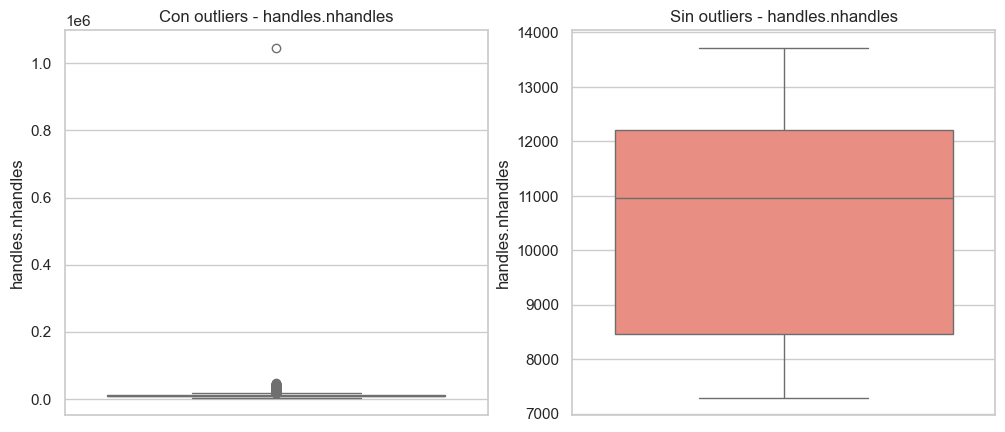

In [16]:
# ===============================
# 6. Comparación visual de outliers
# ===============================
col_example = "handles.nhandles"  # puedes probar con otras variables
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(y=df[col_example], ax=axes[0], color="skyblue")
axes[0].set_title(f"Con outliers - {col_example}")

sns.boxplot(y=df_no_outliers[col_example], ax=axes[1], color="salmon")
axes[1].set_title(f"Sin outliers - {col_example}")

plt.show()

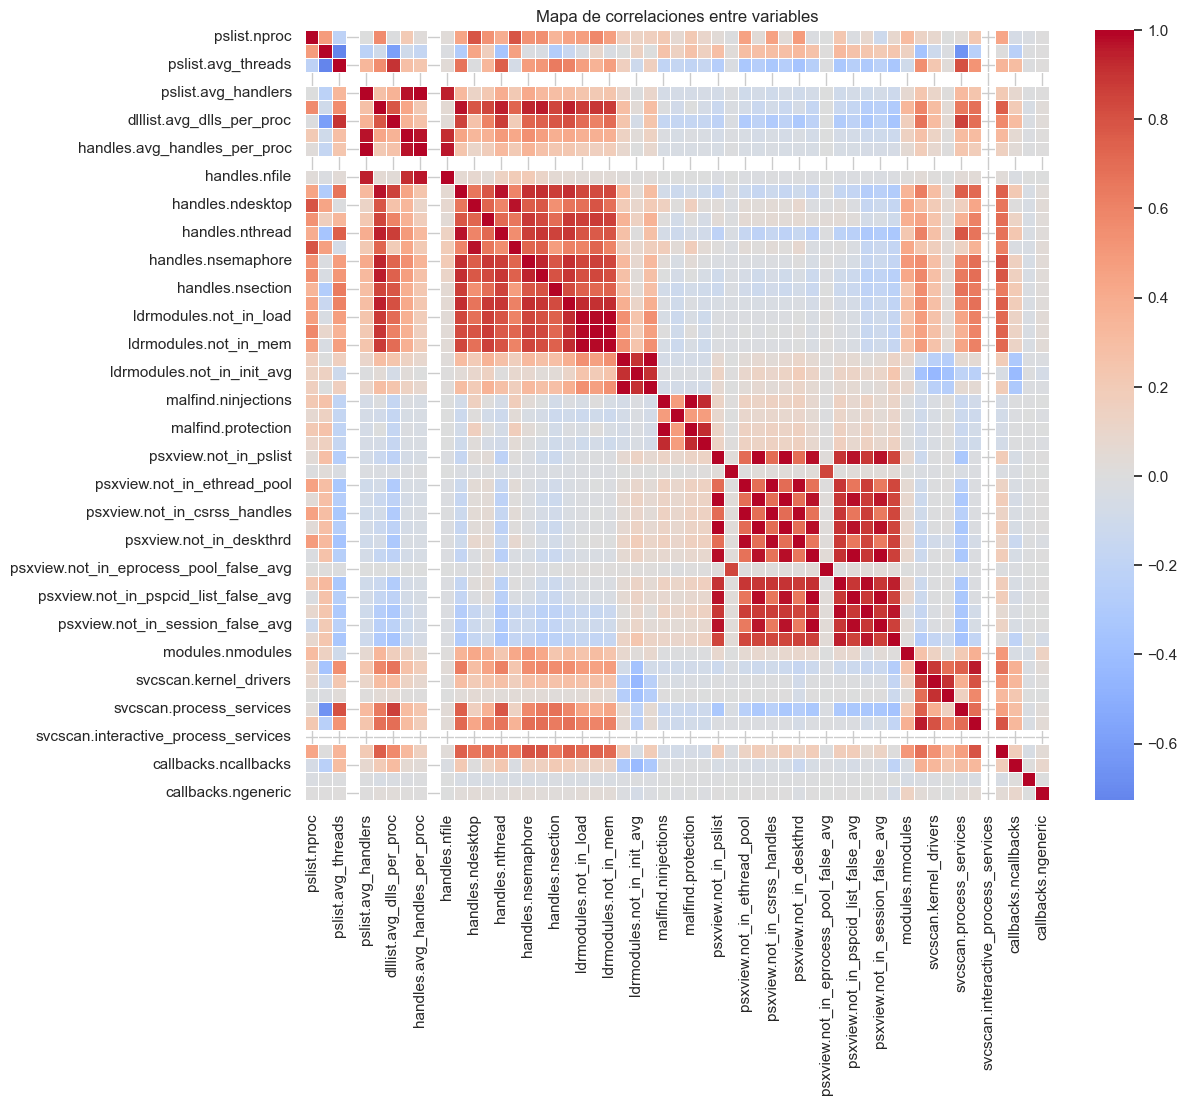

In [17]:
# ===============================
# 7. Correlación de variables
# ===============================
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Mapa de correlaciones entre variables")
plt.show()


En ciberseguridad, los outliers suelen ser las huellas más claras de ataques.
Por ejemplo:
- Un número excesivo de handles puede indicar malware escaneando el sistema.
- Inyecciones de memoria fuera de lo común (malfind.*) revelan ofuscación.
- Procesos ocultos detectados en psxview son casos atípicos, no ruido.

Si eliminamos estos registros, el modelo pierde justamente las señales más importantes.
Por eso, en este dataset NO es recomendable eliminar outliers.